In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings("ignore")


In [ ]:
team_ratings = pd.read_csv("team_ratings.csv", parse_dates = ['DATE'])
team_metrics = pd.read_csv("team_metrics.csv", parse_dates = ['GAME_DATE'], dtype = {'GAME_ID': object, 'TEAM_ID': object, 'HOME_TEAM_ID': object, 'AWAY_TEAM_ID': object})
nba_teams = pd.read_csv("teams_glossary.csv", dtype={'TEAM_ID': object})
glossary = pd.read_csv('metrics_glossary.csv')

In [ ]:
game_outcomes = pd.read_csv("game_outcomes.csv", parse_dates = ['GAME_DATE'], dayfirst = True, dtype={'GAME_ID': object})

In [251]:
team_ratings_detailed = team_ratings.merge(nba_teams, how = 'left', on = 'TEAM_FULL_NAME')
metrics_detailed = pd.merge(left = team_metrics, right = team_ratings_detailed, how = 'left', left_on = ['TEAM_ID', 'GAME_DATE'], right_on = ['TEAM_ID', 'DATE'])


In [252]:
# Final rating per season per team (latest date)
team_ratings_seasonal = team_ratings.sort_values('DATE').groupby(['SEASON', 'TEAM_FULL_NAME']).tail(1)

In [253]:
team_ratings_seasonal.to_csv("team_ratings_seasonal.csv", index=False)

In [254]:
team_ratings_seasonal = pd.read_csv("team_ratings_seasonal.csv", parse_dates = ['DATE'])

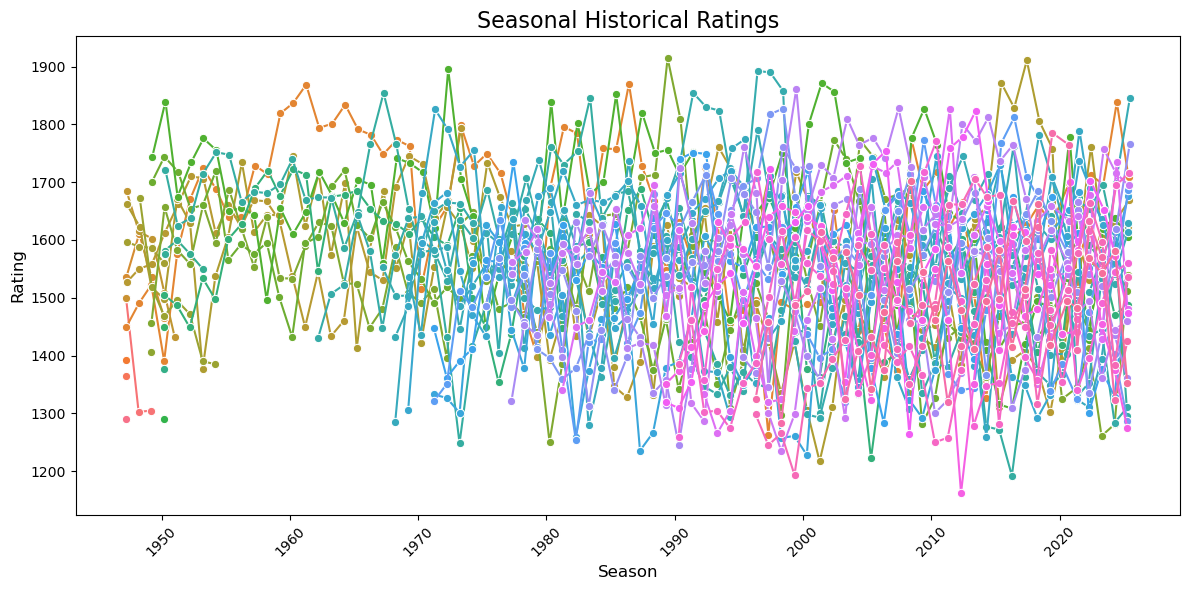

In [255]:
# Create the plot
plt.figure(figsize=(12, 6), layout = 'tight')

sns.lineplot(
    data=team_ratings_seasonal,
    x='DATE',
    y='RATING',
    hue='TEAM_FULL_NAME',
    marker='o',
    linewidth=1.5,
    legend=False
)

# Customize axes and title
plt.title('Seasonal Historical Ratings', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


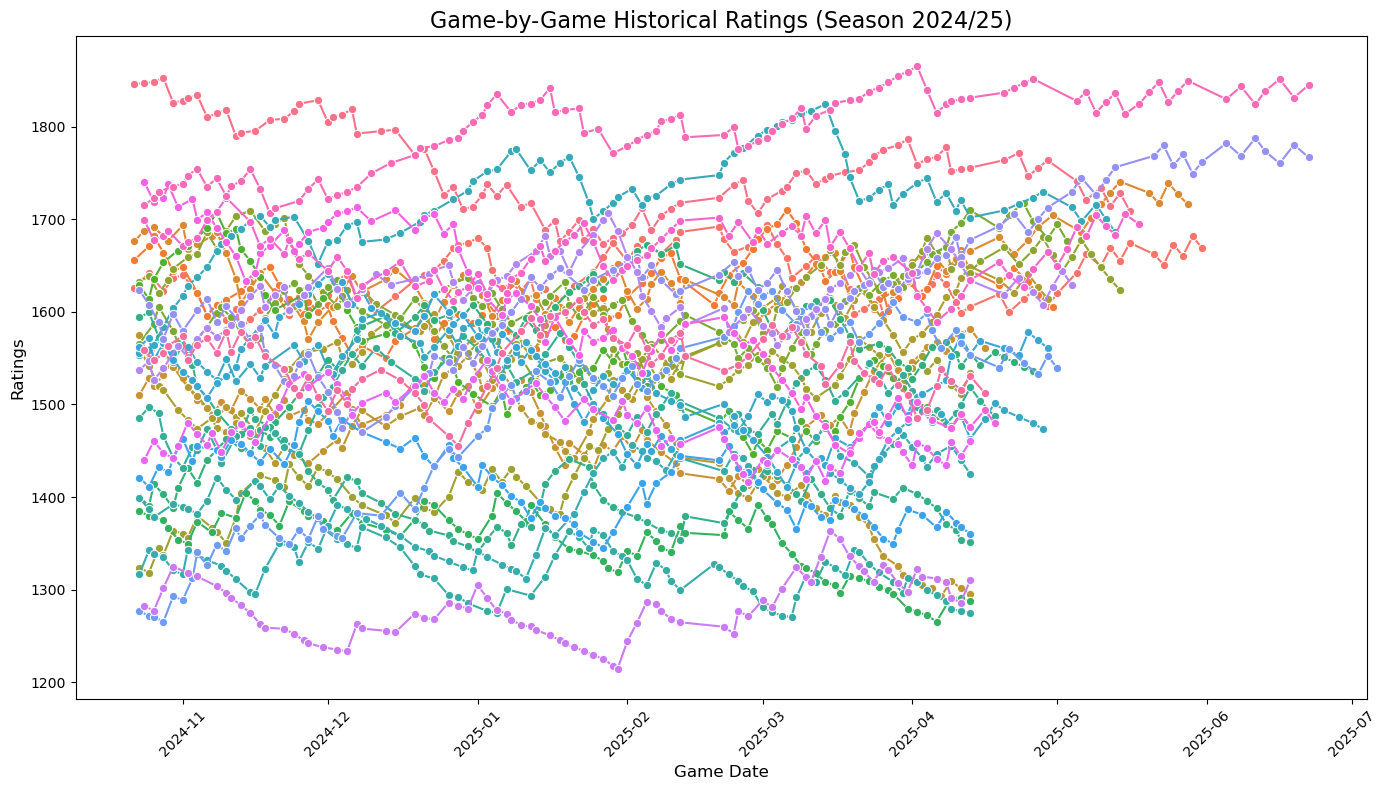

In [256]:
current_season = "2024/25"
team_ratings_filtered = team_ratings[team_ratings["SEASON"] == current_season]

# Create the plot
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=team_ratings_filtered,
    x='DATE',
    y='RATING',
    hue='TEAM_FULL_NAME',
    marker='o',
    linewidth=1.5,
    legend = False
)

# Customize axes and title
plt.title(f'Game-by-Game Historical Ratings (Season {current_season})', fontsize=16)
plt.xlabel('Game Date', fontsize=12)
plt.ylabel('Ratings', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [257]:
metrics_corr = metrics_detailed.drop(['GAME_ID', 'TEAM_ID', 'GAME_DATE', 'SEASON_TYPE', 'YEAR', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'SIDE', 'WINLOSS', 'TRAD_PLUS_MINUS', 'TRAD_MIN', 'ADV_REB_PCT', 'ADV_PIE', 'DATE', 'SEASON', 'TEAM_FULL_NAME', 'TEAM_NAME', 'FIRST_SEASON', 'LAST_SEASON', 'TEAM_ABBR'], axis = 1)

corr_rating = pd.DataFrame(metrics_corr.corrwith(metrics_corr["RATING"])).drop(index = "RATING").sort_values(by=0, ascending=False).reset_index()
corr_rating.columns = ['Metric', 'Correlation']

top_corr_rating = corr_rating.head(6).merge(glossary, how = 'left', on = 'Metric')

In [258]:
top_corr_rating

,Metric,Correlation,Name,Description
0,ADV_NETRTG,0.339778,Net Rating,Point differential per 100 possessions (points...
1,ADV_TS_PCT,0.242459,True Shooting Percentage,Shooting percentage that factors in the value ...
2,ADV_OFFRTG,0.225873,Offensive Rating,Points scored per 100 possessions
3,FF_EFG_PCT,0.192103,Effective Field Goal Percentage,Field goal percentage adjusting for made 3-poi...
4,TRAD_FG_PCT,0.173711,Field Goal Percentage,The percentage of field goal attempts a team m...
5,TRAD_PTS,0.153640,Points,Number of points scored


In [259]:
top_corr_rating.to_csv("drivers_of_ratings_top.csv", index=False)

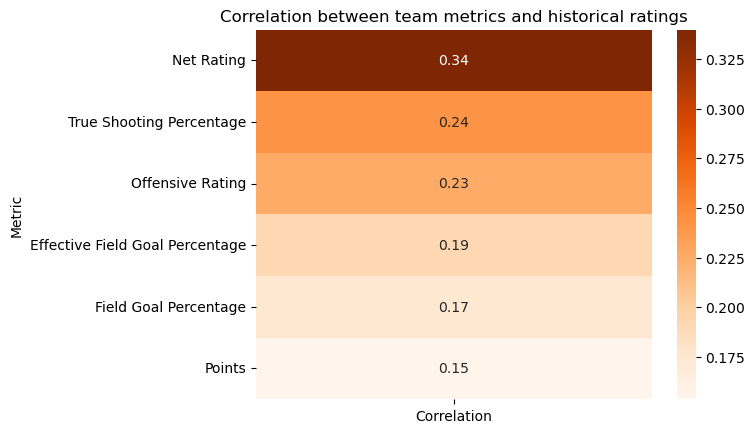

In [260]:
heatmap_data = top_corr_rating[['Name', 'Correlation']].set_index("Name")
sns.heatmap(heatmap_data, annot = True, fmt = ".2f", cmap = "Oranges")
plt.ylabel("Metric")
plt.title("Correlation between team metrics and historical ratings")
plt.show()

In [261]:
top_metrics = top_corr_rating['Metric'].to_list()

metrics_per_season_columns = top_metrics + ['SEASON', 'RATING']

metrics_per_season = metrics_detailed[metrics_per_season_columns]

# Function to compute correlation between each metric and rating for a given year
def yearwise_corr(group):
    return group[top_metrics + ['RATING']].corr()['RATING'].drop('RATING')

# Apply the function to each year group
correlations_per_season = metrics_per_season.groupby('SEASON').apply(yearwise_corr, include_groups=False).reset_index()

correlations_per_season_melted = correlations_per_season.melt(id_vars="SEASON", var_name="Metric", value_name="Correlation")

seasonal_correlations = correlations_per_season_melted.merge(glossary, on = 'Metric')

In [262]:
seasonal_correlations.to_csv("drivers_of_ratings_seasonal.csv", index=False)

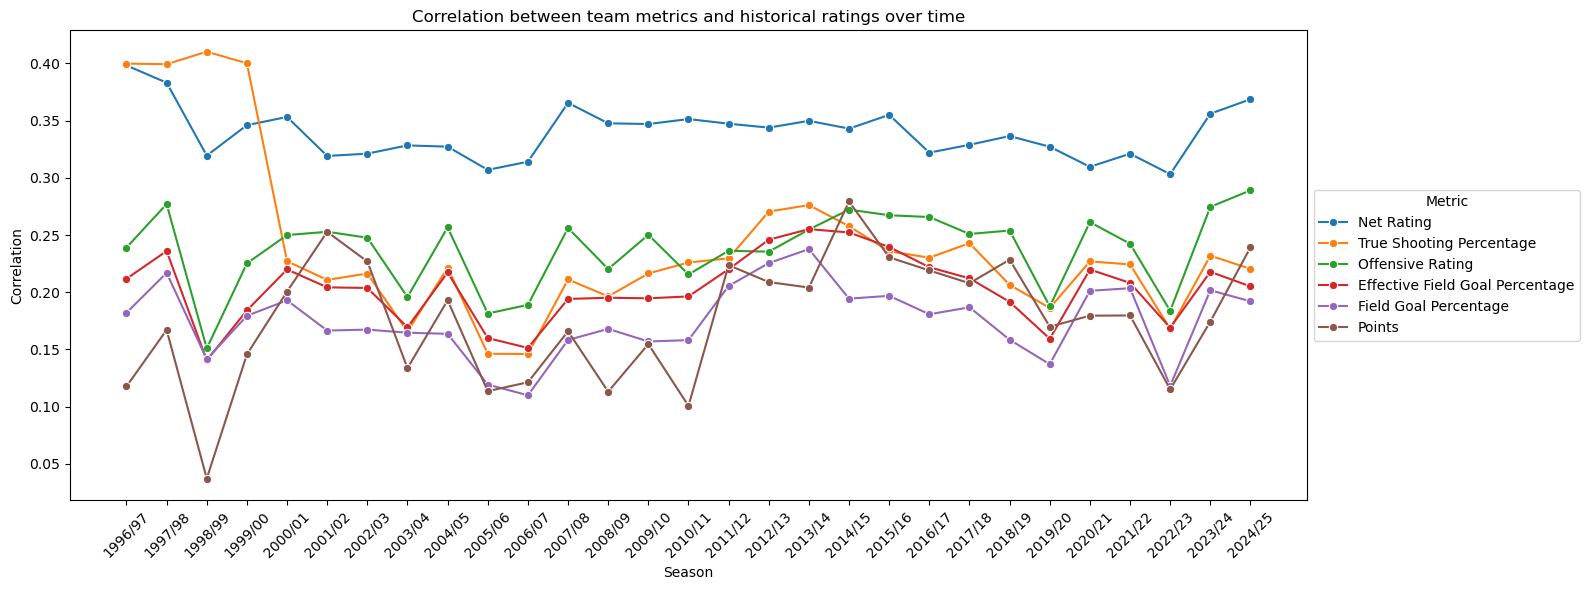

In [263]:
# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=seasonal_correlations, x="SEASON", y="Correlation", hue="Name", palette="tab10", marker='o', linewidth=1.5)
plt.title("Correlation between team metrics and historical ratings over time")
plt.xlabel("Season")
plt.ylabel("Correlation")
plt.legend(title="Metric", loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# for each season, calculate the average metric for the championship team vs league average



In [280]:
# List of metric columns to average
metric_cols = [
    'TRAD_PTS', 'TRAD_FGM', 'TRAD_FGA', 'TRAD_FG_PCT', 'TRAD_3PM', 'TRAD_3PA',
    'TRAD_3P_PCT', 'TRAD_FTM', 'TRAD_FTA', 'TRAD_FT_PCT', 'TRAD_OREB',
    'TRAD_DREB', 'TRAD_REB', 'TRAD_AST', 'TRAD_TOV', 'TRAD_STL', 'TRAD_BLK',
    'TRAD_PF', 'ADV_OFFRTG', 'ADV_DEFRTG',
    'ADV_AST_PCT', 'ADV_AST_TO', 'ADV_OREB_PCT',
    'ADV_DREB_PCT', 'ADV_TS_PCT', 'ADV_PACE', 
    'FF_EFG_PCT', 'FF_FTA_RATE', 'FF_TOV_PCT', 'FF_OREB_PCT',
    'FF_OPP_EFG_PCT', 'FF_OPP_FTA_RATE', 'FF_OPP_TOV_PCT', 'FF_OPP_OREB_PCT',
    'MISC_PTS_OFF_TO', 'MISC_2ND_PTS', 'MISC_FBPS', 'MISC_PITP',
    'MISC_OPP_PTS_OFF_TO', 'MISC_OPP_2ND_PTS', 'MISC_OPP_FBPS', 'MISC_OPP_PITP',
    'SCOR_PCTFGA_2PT', 'SCOR_PCTFGA_3PT', 'SCOR_PCTPTS_2PT', 'SCOR_PCTPTS_2PT_MR',
    'SCOR_PCTPTS_3PT', 'SCOR_PCTPTS_FBPS', 'SCOR_PCTPTS_FT', 'SCOR_PCTPTS_OFF_TO',
    'SCOR_PCTPTS_PITP', 'SCOR_2FGM__PCTAST', 'SCOR_2FGM__PCTUAST',
    'SCOR_3FGM__PCTAST', 'SCOR_3FGM__PCTUAST', 'SCOR_FGM__PCTAST', 'SCOR_FGM__PCTUAST'
]

# Group by SEASON and calculate mean for each metric
season_avg_metrics = metrics_detailed.groupby('SEASON')[metric_cols].mean().reset_index()

In [281]:
season_avg_metrics.to_csv("team_metrics_seasonal.csv", index=False)

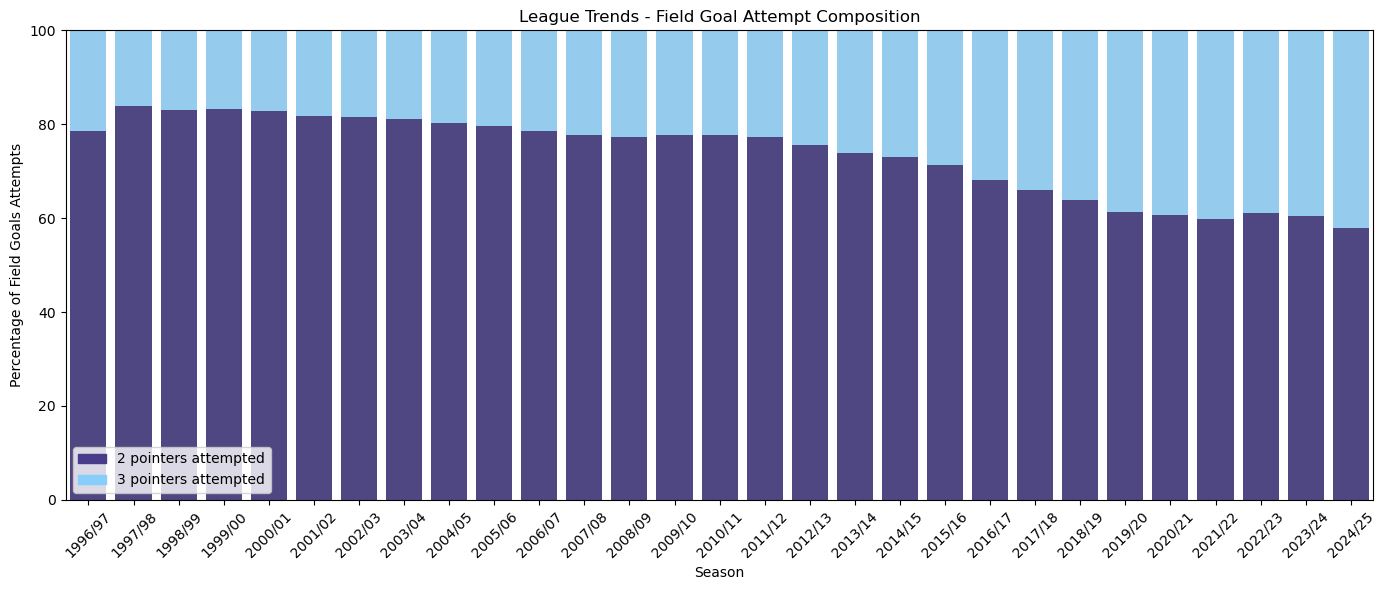

In [291]:
# PERCENTAGE OF FIELD GOALS ATTEMPTED AS 2PT VS 3PT

PCT_FGA_PTS_columns = ['SCOR_PCTFGA_2PT', 'SCOR_PCTFGA_3PT']
PCT_FGA_PTS_season_avg = season_avg_metrics[['SEASON'] + PCT_FGA_PTS_columns]

# Create separate DataFrames for stacking
fga_2pt = PCT_FGA_PTS_season_avg[['SEASON', 'SCOR_PCTFGA_2PT']]
fga_2pt.rename(columns={'SCOR_PCTFGA_2PT': 'Percentage'}, inplace=True)

fga_3pt = PCT_FGA_PTS_season_avg[['SEASON', 'SCOR_PCTFGA_3PT']]
fga_3pt.rename(columns={'SCOR_PCTFGA_3PT': 'Percentage'}, inplace=True)

# Plot
plt.figure(figsize=(14, 6))

# Bottom layer: 2PT FGA
sns.barplot(x='SEASON', y='Percentage', data=fga_2pt, color='darkslateblue')

# Top layer: 3PT FGA stacked on top
sns.barplot(x='SEASON', y='Percentage', data=fga_3pt, color='lightskyblue', bottom=fga_2pt['Percentage'])

# Legend
bottom_patch = mpatches.Patch(color='darkslateblue', label='2 pointers attempted')
top_patch = mpatches.Patch(color='lightskyblue', label='3 pointers attempted')
plt.legend(handles=[bottom_patch, top_patch], loc = "lower left")

# Labels and formatting
plt.title('League Trends - Field Goal Attempt Composition')
plt.xlabel('Season')
plt.ylabel('Percentage of Field Goals Attempts')
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


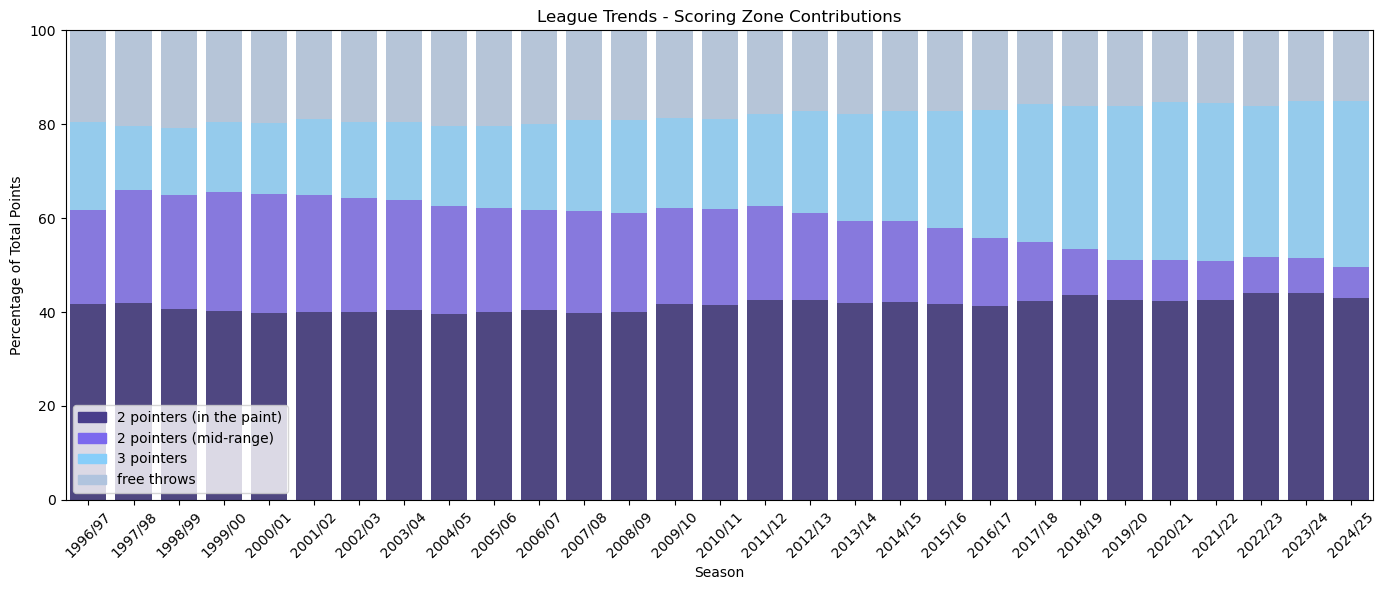

In [292]:
# PERCENTAGE OF FIELD GOALS ATTEMPTED AS ZONES
PCT_FGA_zones_columns = ['SCOR_PCTPTS_PITP','SCOR_PCTPTS_2PT_MR','SCOR_PCTPTS_3PT', 'SCOR_PCTPTS_FT']
PCT_FGA_season_avg = season_avg_metrics[['SEASON'] + PCT_FGA_zones_columns]

# Create stacked layers
pitp = PCT_FGA_season_avg[['SEASON', 'SCOR_PCTPTS_PITP']].rename(columns={'SCOR_PCTPTS_PITP': 'Percentage'})
midrange = PCT_FGA_season_avg[['SEASON', 'SCOR_PCTPTS_2PT_MR']].rename(columns={'SCOR_PCTPTS_2PT_MR': 'Percentage'})
threept = PCT_FGA_season_avg[['SEASON', 'SCOR_PCTPTS_3PT']].rename(columns={'SCOR_PCTPTS_3PT': 'Percentage'})
ft = PCT_FGA_season_avg[['SEASON', 'SCOR_PCTPTS_FT']].rename(columns={'SCOR_PCTPTS_FT': 'Percentage'})

# Plot
plt.figure(figsize=(14, 6))

sns.barplot(x='SEASON', y='Percentage', data=pitp, color='darkslateblue')
sns.barplot(x='SEASON', y='Percentage', data=midrange, color='mediumslateblue', bottom=pitp['Percentage'])
sns.barplot(x='SEASON', y='Percentage', data=threept, color='lightskyblue', bottom=pitp['Percentage'] + midrange['Percentage'])
sns.barplot(x='SEASON', y='Percentage', data=ft, color='lightsteelblue', bottom=pitp['Percentage'] + midrange['Percentage'] + threept['Percentage'])

# Legend
patches = [
    mpatches.Patch(color='darkslateblue', label='2 pointers (in the paint)'),
    mpatches.Patch(color='mediumslateblue', label='2 pointers (mid-range)'),
    mpatches.Patch(color='lightskyblue', label='3 pointers'),
    mpatches.Patch(color='lightsteelblue', label='free throws')
]
plt.legend(handles=patches, loc = 'lower left')

# Labels and formatting
plt.title('League Trends - Scoring Zone Contributions')
plt.xlabel('Season')
plt.ylabel('Percentage of Total Points')
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


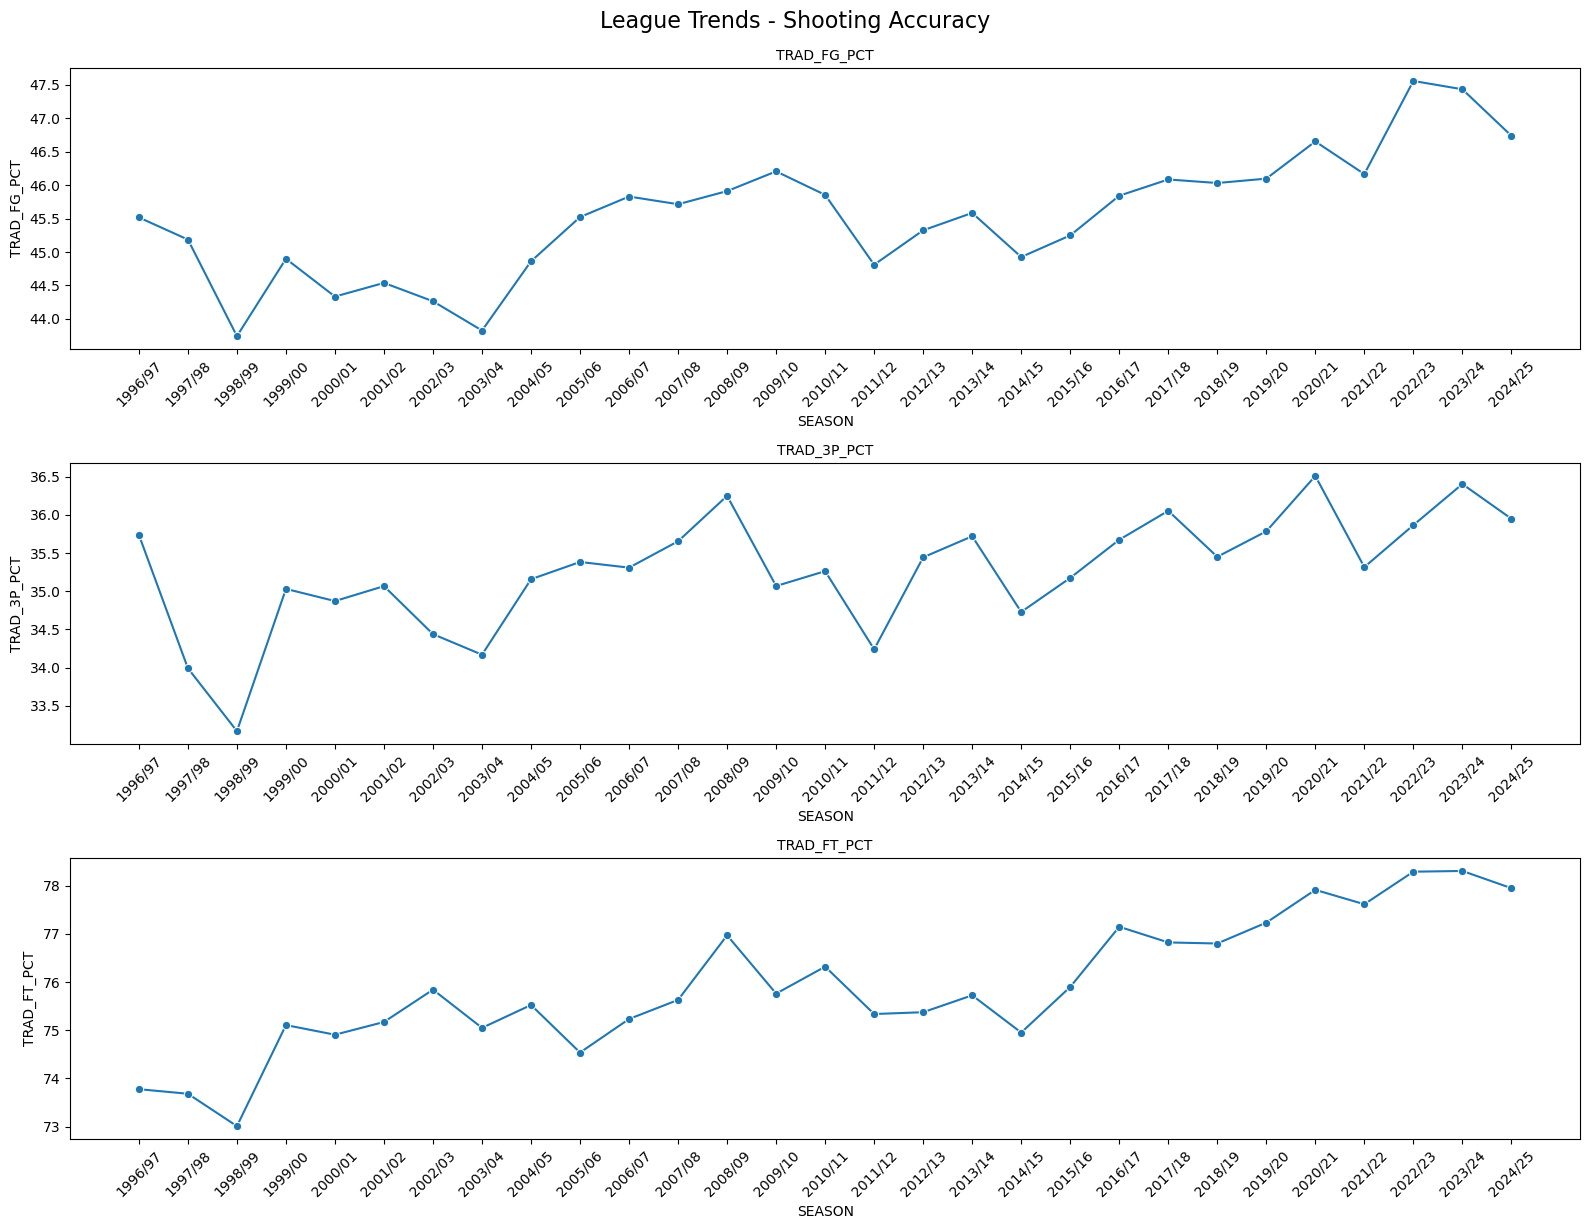

In [299]:
# metrics to analyse
shooting_PCTS = ['TRAD_FG_PCT', 'TRAD_3P_PCT', 'TRAD_FT_PCT']

num_metrics = len(shooting_PCTS)

# Define grid size (e.g., 6 columns)
cols = 1
rows = 3

# Set figure size based on grid
plt.figure(figsize=(16, rows * 4))

# Loop through each metric and plot
for i, metric in enumerate(shooting_PCTS):
    plt.subplot(rows, cols, i+1)
    sns.lineplot(data=season_avg_metrics, x='SEASON', y=metric, marker='o', linewidth=1.5)
    plt.title(metric, fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('League Trends - Shooting Accuracy', fontsize=16, y=1.02)
plt.show()


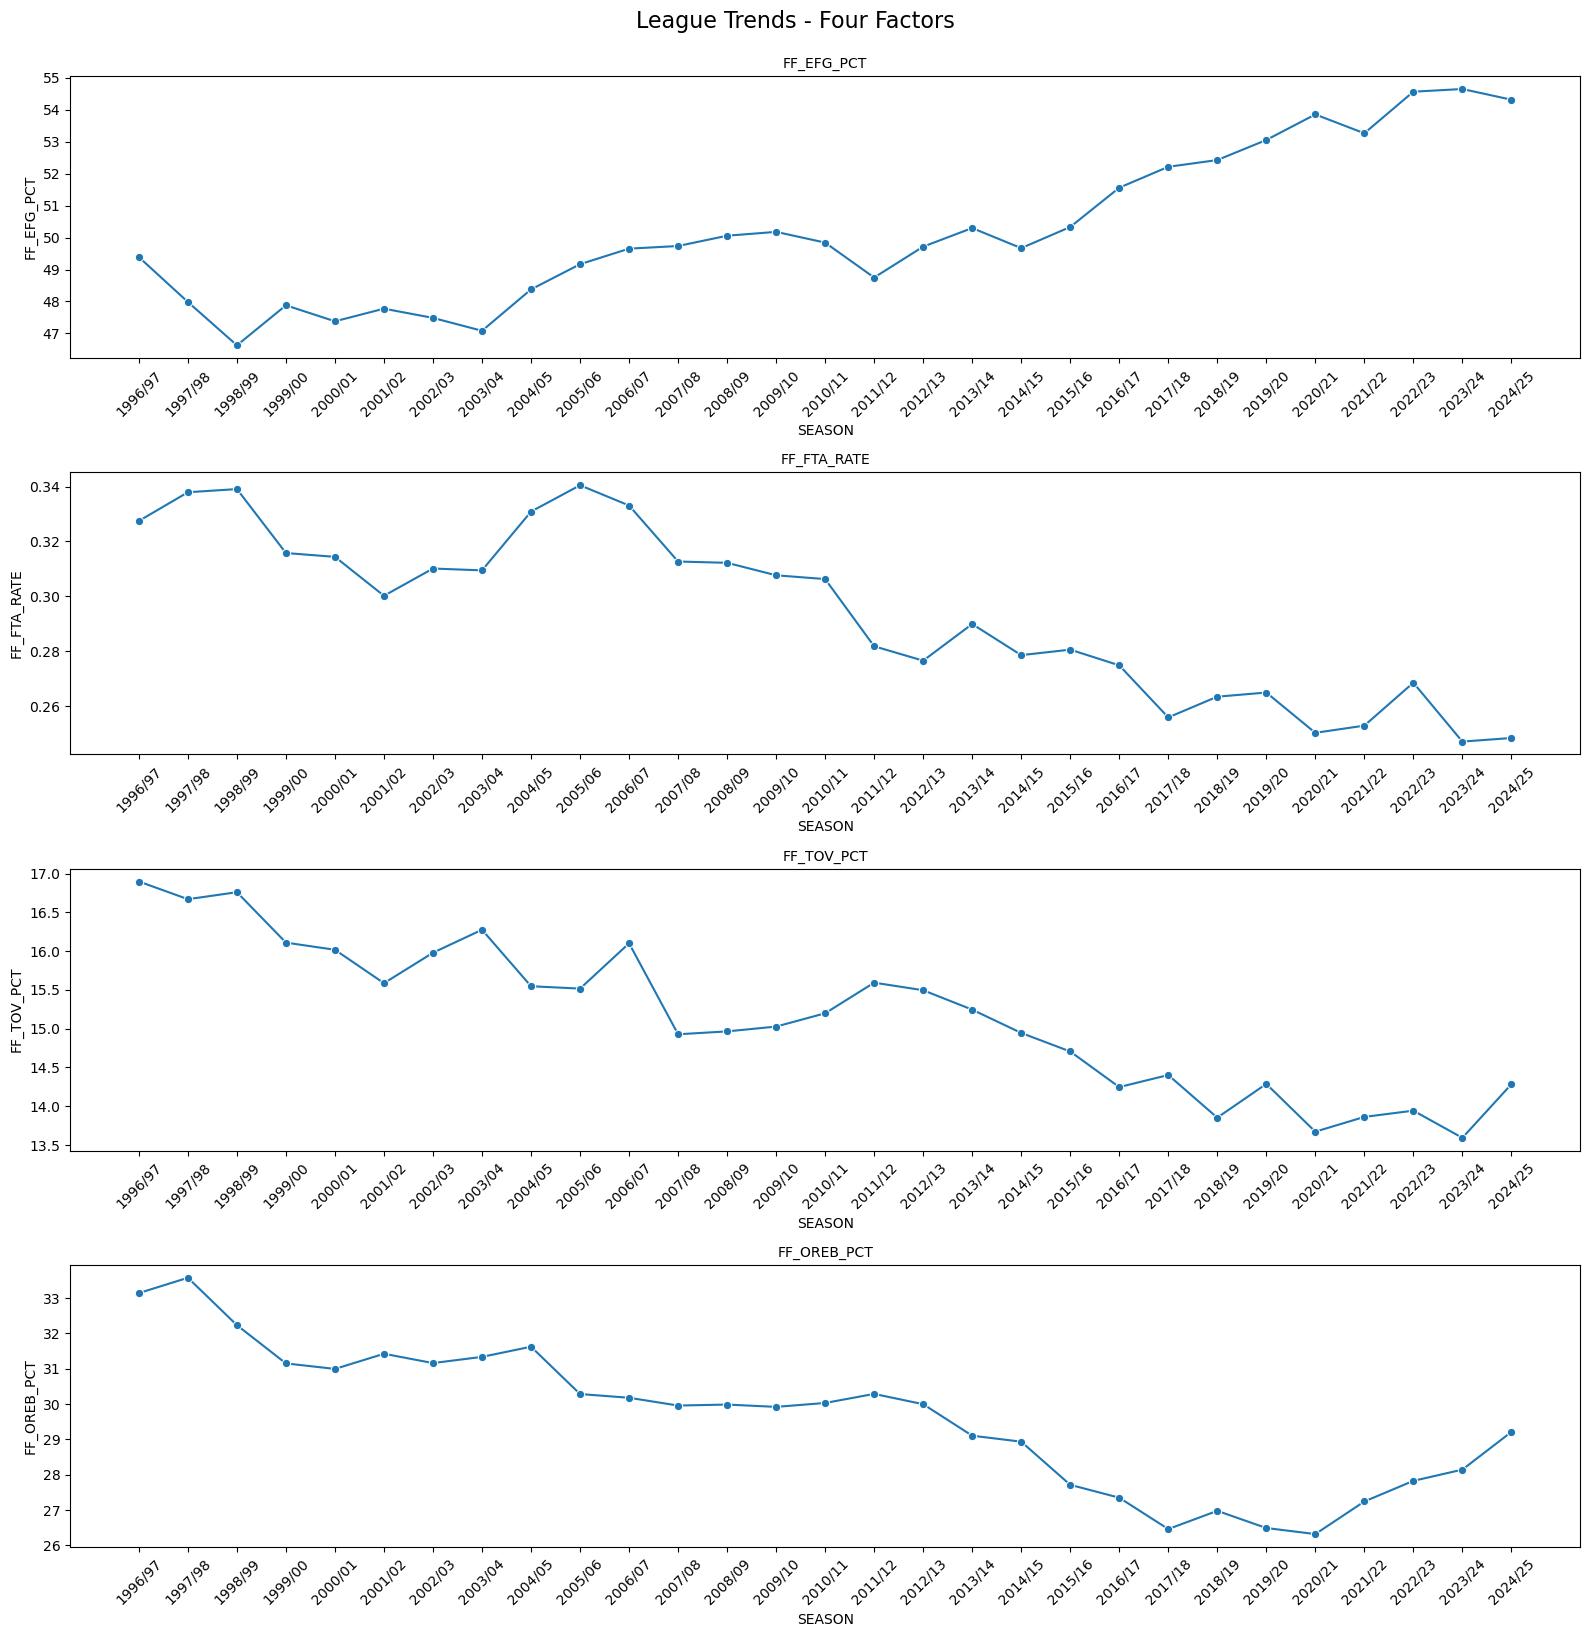

In [305]:
# metrics to analyse
four_factors = ['FF_EFG_PCT', 'FF_FTA_RATE', 'FF_TOV_PCT', 'FF_OREB_PCT']

num_metrics = len(four_factors)

# Define grid size (e.g., 6 columns)
cols = 1
rows = 4

# Set figure size based on grid
plt.figure(figsize=(16, rows * 4))

# Loop through each metric and plot
for i, metric in enumerate(four_factors):
    plt.subplot(rows, cols, i+1)
    sns.lineplot(data=season_avg_metrics, x='SEASON', y=metric, marker='o', linewidth=1.5)
    plt.title(metric, fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('League Trends - Four Factors', fontsize=16, y=1.02)
plt.show()


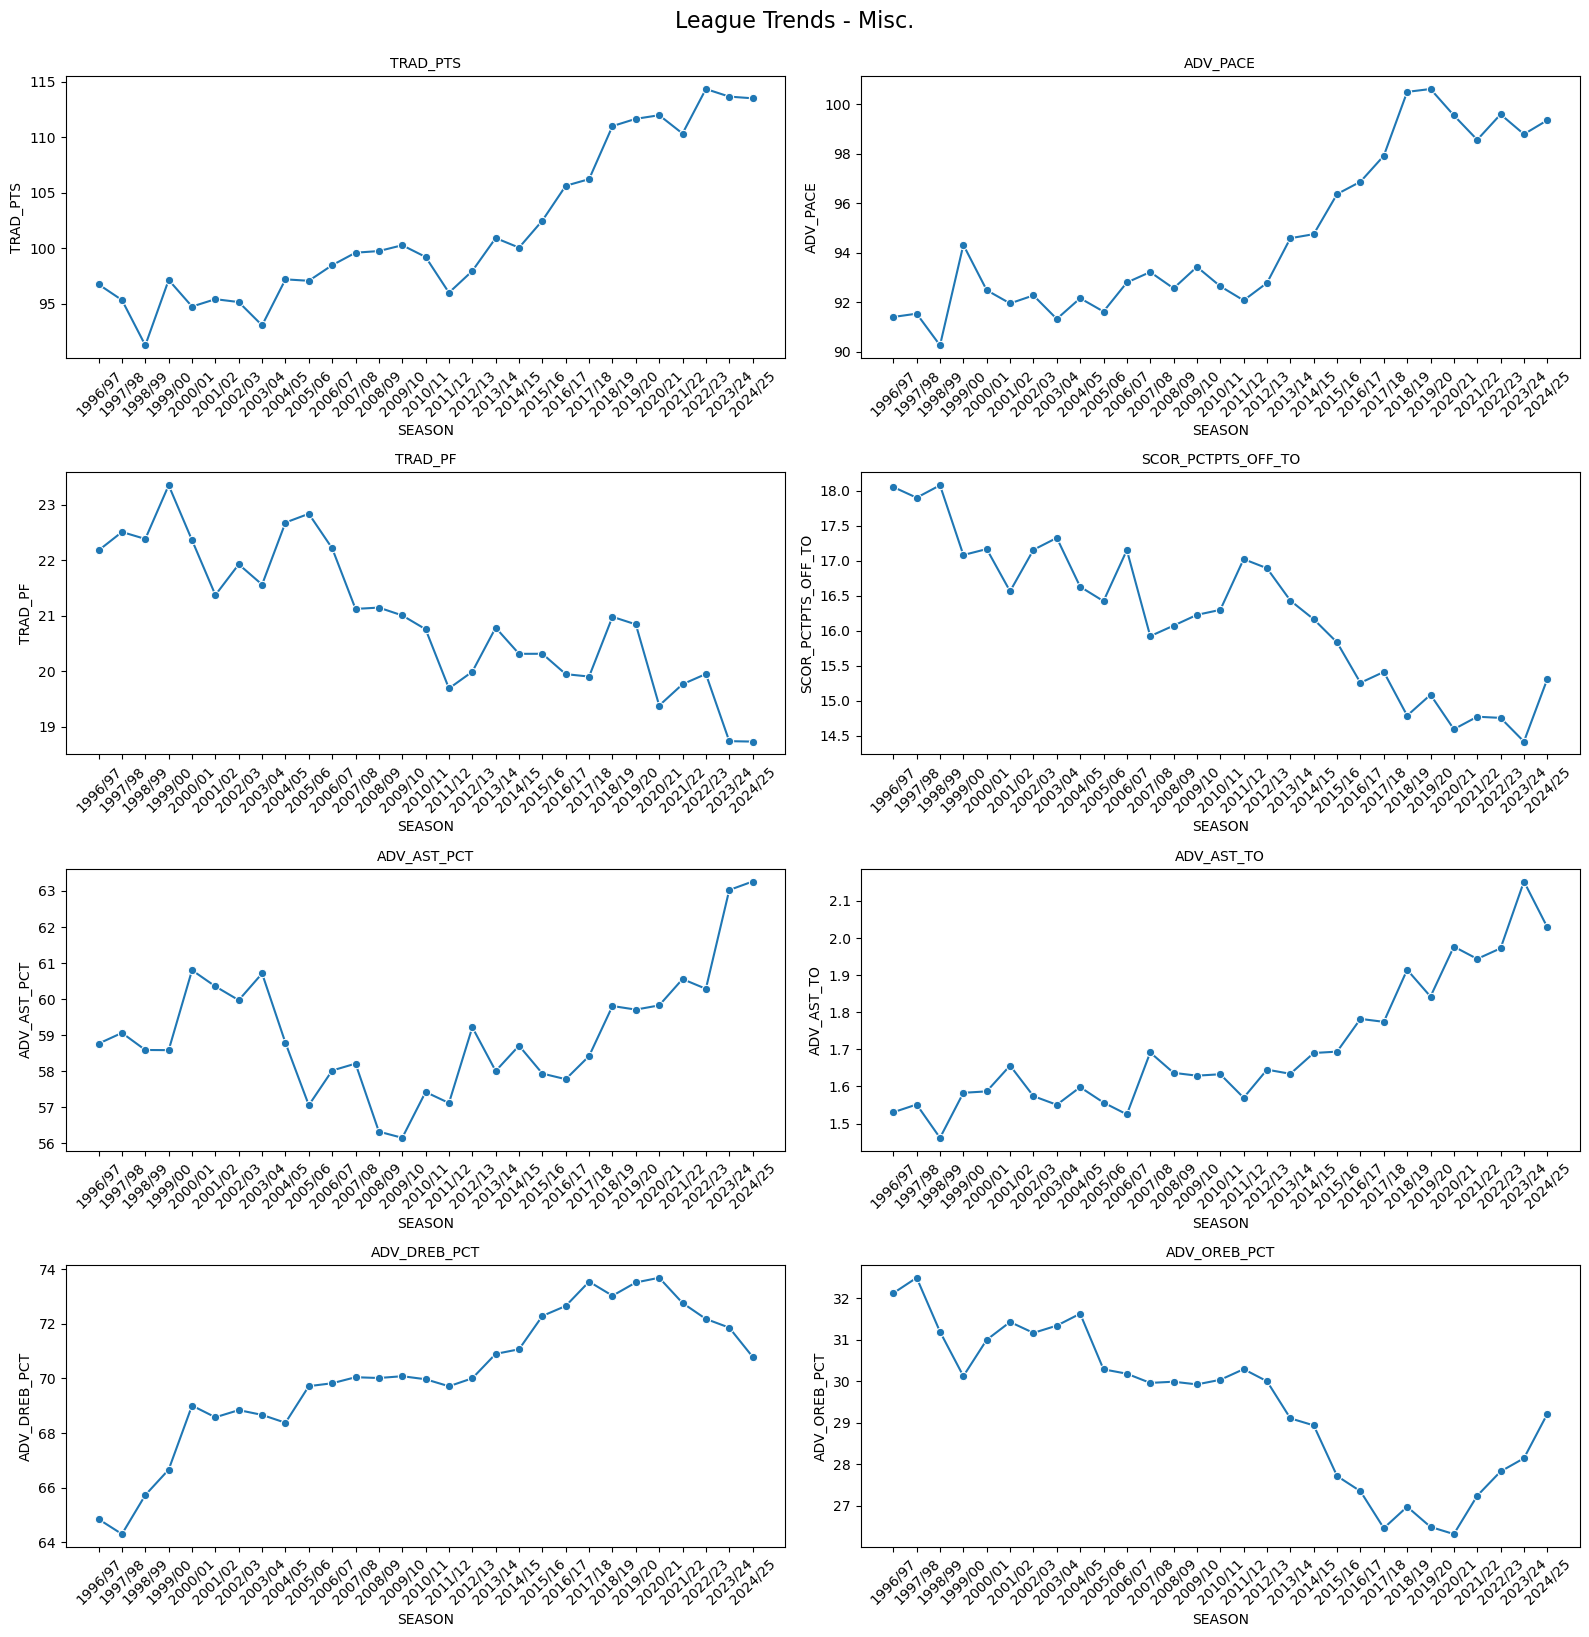

In [306]:
misc_metrics = [
    'TRAD_PTS', 'ADV_PACE',
    'TRAD_PF', 'SCOR_PCTPTS_OFF_TO', 
    'ADV_AST_PCT', 'ADV_AST_TO', 
    'ADV_DREB_PCT', 'ADV_OREB_PCT'
]

num_metrics = len(misc_metrics)

# Define grid size (e.g., 6 columns)
cols = 2
rows = 4

# Set figure size based on grid
plt.figure(figsize=(16, rows * 4))

# Loop through each metric and plot
for i, metric in enumerate(misc_metrics):
    plt.subplot(rows, cols, i+1)
    sns.lineplot(data=season_avg_metrics, x='SEASON', y=metric, marker='o', linewidth=1.5)
    plt.title(metric, fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('League Trends - Misc.', fontsize=16, y=1.02)
plt.show()
